In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

cuda:0


Dodaliśmy normalizację naszych danych, aby gradienty były równe, a trening szybszy.
Jako, że nie mamy zbyt wielu danych to robimy ich augumentacje za pomocą RandomCrop oraz RandomHorizontalFlip.
BatchSize to 128 - klasyczny rozmiar dla naszego modelu

Po pierwszych testach naszego modelu dodaliśmy również ColorJitter - odporność na oświetlenie i tło oraz RandomErasing - wymuszanie, aby model nie operał się jedynie na jednym fragmencie, lecz na globalnych cechach.

In [4]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=True
)

100%|██████████| 170M/170M [00:02<00:00, 77.6MB/s]


In [5]:
classes = (
"airplane",
"automobile",
"bird",
"cat",
"deer",
"dog",
"frog",
"horse",
"ship",
"truck"
)

print(type(testset[0][0]))

<class 'torch.Tensor'>


CIFAR-10 to zbiór danych do uczenia maszynowego i widzenia komputerowego.
Zawiera 60 000 kolorowych obrazów 32×32 px, podzielonych na 10 klas (m.in. samolot, samochód, ptak, kot, pies).
Standardowo 50 000 obrazów służy do treningu, a 10 000 do testów.

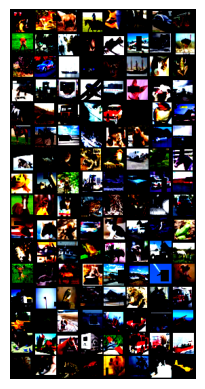

dog        deer       horse      horse      dog        bird       automobile truck     
deer       cat        deer       cat        frog       airplane   cat        bird      
deer       automobile ship       airplane   deer       ship       cat        frog      
horse      truck      cat        airplane   airplane   dog        bird       airplane  
horse      deer       truck      ship       automobile bird       bird       horse     
horse      horse      airplane   ship       cat        dog        ship       airplane  
deer       bird       bird       frog       bird       truck      bird       horse     
frog       truck      cat        truck      automobile automobile truck      ship      
horse      bird       cat        frog       deer       cat        cat        automobile
bird       cat        dog        automobile cat        truck      bird       frog      
frog       airplane   ship       frog       bird       bird       truck      horse     
deer       bird       deer      

In [6]:
import matplotlib.pyplot as plt
import numpy as np


def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()


dataiter = iter(trainloader)
images, labels = next(dataiter)

def grid_show(images, nrow=8):
    imshow(torchvision.utils.make_grid(images, nrow=nrow))


def print_grid(labels, nrow=8):
    rows = [labels[n : n + nrow] for n in range(0, len(labels), nrow)]
    for r in rows:
        print(" ".join(f"{classes[c]:10s}" for c in r))

grid_show(images)
print_grid(labels)


In [7]:
import torch.nn as nn
import torch.nn.functional as F


import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
from torchvision.models import resnet18

def make_resnet18_cifar(num_classes=10):
    model = resnet18(weights=None)

    model.conv1 = nn.Conv2d(
        3, 64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    model.maxpool = nn.Identity()

    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

In [8]:
net = make_resnet18_cifar()
net = net.to(device)

Liczba epok to 50 - standard.
Dla zmniejszenia overfittingu uzyliśmy Label smoothing (CrossEntropyLoss), model jest dzięki temu mniej pewny siebie.
Dodaliśmy regularyzacje L2 (penalizacja za duże wagi) wraz z AdamW.
Zapewniliśmy malenie lr w czasie za pomocą CosineAnnealingLR.


In [9]:
import torch.optim as optim

epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = make_resnet18_cifar().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

Zastosowaliśmy MixUp dla zwiększenia generalizacji - wygładza on granice decyzyjne

In [10]:
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b,)

def mixup_correct_count(pred_logits, y_a, y_b, lam):
    pred = pred_logits.argmax(dim=1)
    return (lam * (pred == y_a).float() + (1 - lam) * (pred == y_b).float()).sum().item()

In [11]:
import torch

def train_model(
    net,
    trainloader,
    optimizer,
    criterion,
    device,
    epochs=50,
    scheduler=None,
    mixup_alpha=0.2,
    print_every=1
):
    net.to(device)

    for epoch in range(epochs):
        net.train()
        running_loss = 0.0
        correct_soft = 0.0
        total = 0

        for images, labels in trainloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if mixup_alpha and mixup_alpha > 0:
                images, y_a, y_b, lam = mixup_data(images, labels, alpha=mixup_alpha)
                outputs = net(images)
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
                correct_soft += mixup_correct_count(outputs, y_a, y_b, lam)
            else:
                outputs = net(images)
                loss = criterion(outputs, labels)
                correct_soft += (outputs.argmax(1) == labels).float().sum().item()

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            total += labels.size(0)

        if scheduler is not None:
            scheduler.step()

        avg_loss = running_loss / total
        acc_soft = 100.0 * correct_soft / total

        if (epoch + 1) % print_every == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(f"Epoch [{epoch+1}/{epochs}]  loss: {avg_loss:.4f}  acc(soft): {acc_soft:.2f}%  lr: {lr:.6f}")

In [12]:
train_model(
    net=net,
    trainloader=trainloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs,
    scheduler=scheduler,
    mixup_alpha=0.2
)

Epoch [1/50]  loss: 1.7641  acc(soft): 43.01%  lr: 0.000999
Epoch [2/50]  loss: 1.4598  acc(soft): 59.46%  lr: 0.000996
Epoch [3/50]  loss: 1.3111  acc(soft): 66.76%  lr: 0.000991
Epoch [4/50]  loss: 1.2622  acc(soft): 69.38%  lr: 0.000984
Epoch [5/50]  loss: 1.2163  acc(soft): 71.38%  lr: 0.000976
Epoch [6/50]  loss: 1.1637  acc(soft): 73.62%  lr: 0.000965
Epoch [7/50]  loss: 1.1564  acc(soft): 73.75%  lr: 0.000952
Epoch [8/50]  loss: 1.1290  acc(soft): 74.88%  lr: 0.000938
Epoch [9/50]  loss: 1.0749  acc(soft): 77.19%  lr: 0.000922
Epoch [10/50]  loss: 1.0666  acc(soft): 77.77%  lr: 0.000905
Epoch [11/50]  loss: 1.0417  acc(soft): 78.65%  lr: 0.000885
Epoch [12/50]  loss: 1.0179  acc(soft): 79.68%  lr: 0.000864
Epoch [13/50]  loss: 0.9672  acc(soft): 81.62%  lr: 0.000842
Epoch [14/50]  loss: 1.0186  acc(soft): 79.82%  lr: 0.000819
Epoch [15/50]  loss: 0.9717  acc(soft): 82.01%  lr: 0.000794
Epoch [16/50]  loss: 0.9672  acc(soft): 82.03%  lr: 0.000768
Epoch [17/50]  loss: 0.9586  acc(

Zapisanie modelu do pliku

In [13]:
torch.save(net.state_dict(), "YellowSupremeModel.pth")

In [14]:
@torch.no_grad()
def evaluate(net, loader, device, criterion=None):
    net.eval()
    total, correct = 0, 0
    loss_sum = 0.0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = net(images)
        if criterion is not None:
            loss_sum += criterion(outputs, labels).item() * images.size(0)

        pred = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

    acc = 100.0 * correct / total
    loss = loss_sum / total if criterion is not None else None
    return acc, loss

In [15]:
test_acc, test_loss = evaluate(net, testloader, device, criterion)
print(f"TEST  acc: {test_acc:.2f}%   loss: {test_loss:.4f}")

TEST  acc: 94.07%   loss: 0.6643


Możemy zauważyć, że nasz model nie przeucza się, a nawet działa lepiej na nowych danych.

Sprawdzenie accurancy dla każdej z klas

In [16]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def per_class_accuracy(model, loader, device, class_names):
    model.eval()

    num_classes = len(class_names)
    correct = [0] * num_classes
    total = [0] * num_classes

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for label, pred in zip(labels, preds):
            total[label.item()] += 1
            if label == pred:
                correct[label.item()] += 1

    acc_per_class = [
        100.0 * correct[i] / total[i] if total[i] > 0 else 0
        for i in range(num_classes)
    ]

    return acc_per_class

class_names = trainloader.dataset.classes

acc_per_class = per_class_accuracy(net, testloader, device, class_names)

print("Accuracy per class:")
for cls, acc in zip(class_names, acc_per_class):
    print(f"{cls:10s}: {acc:.2f}%")

Accuracy per class:
airplane  : 95.40%
automobile: 97.70%
bird      : 91.90%
cat       : 86.70%
deer      : 94.20%
dog       : 90.40%
frog      : 95.90%
horse     : 96.50%
ship      : 96.50%
truck     : 95.50%


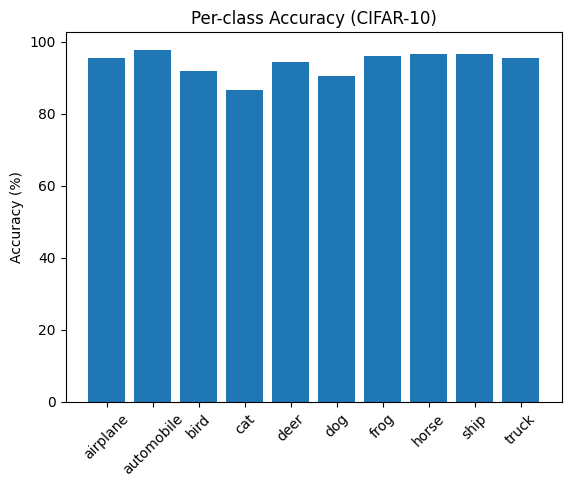

In [17]:
plt.figure()
plt.bar(class_names, acc_per_class)
plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Per-class Accuracy (CIFAR-10)")
plt.show()

W tym momencie, w pierwszej wersji modelu, zaobserwowaliśmy słaby wynik dla kotów (55%) oraz psów (64%). Sprawdziliśmy zatem z czym są one mylone.

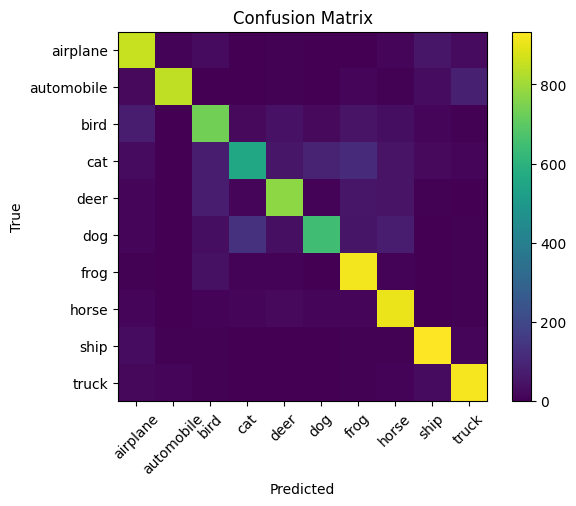

In [18]:
from IPython.display import Image, display
display(Image("images/first_matrix.png"))

Możemy zaobserwować, że koty najczęściej są mylone z żabami oraz z psami. Dodaliśmy z tego względu MixUp, ColorJitter oreaz RandomErasing.

In [19]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_predictions(net, testloader, device)

cm = confusion_matrix(y_true, y_pred)

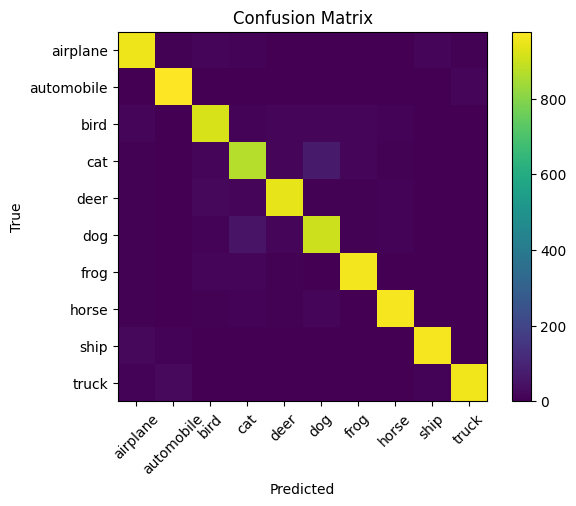

In [20]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(10), trainloader.dataset.classes, rotation=45)
plt.yticks(range(10), trainloader.dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Aktualna macierz pomyłek